In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout ,BatchNormalization
from tensorflow.keras.regularizers import L1, L2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import SGD, Adam
from kerastuner.tuners import RandomSearch
from imblearn.over_sampling import SMOTE,SMOTENC,RandomOverSampler
from collections import Counter
from pca import pca

In [7]:
df = pd.read_csv(r"D:\Kareem\Machine learning Developer\9- Deep Learning-20260328\Kaggel.csv") # train
dftest = pd.read_csv(r"D:\Kareem\Machine learning Developer\9- Deep Learning-20260328\test.csv") # test
df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [8]:
df.loc[:, ["Crop_Type"]].value_counts()

Crop_Type
Sugarcane    108910
Rice         106697
Cotton       104645
Maize        104274
Wheat        103005
Potato       102469
Name: count, dtype: int64

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  str    
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  str    
 12  Crop_Growth_Stage        630000 non-null  str    
 13  Season                   630000 non-null  str    
 14  Irrigation_Type

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.500000,181865.479132,0.00,157499.7500,314999.50,472499.25,629999.00
Soil_pH,630000.0,6.482497,0.922504,4.80,5.6900,6.44,7.27,8.20
Soil_Moisture,630000.0,37.304482,16.377082,8.00,23.3400,37.75,51.27,64.99
Organic_Carbon,630000.0,0.922858,0.365808,0.30,0.6100,0.91,1.22,1.60
Electrical_Conductivity,630000.0,1.744605,0.952321,0.10,0.9300,1.74,2.58,3.50
Temperature_C,630000.0,26.998166,8.623621,12.00,19.5175,26.96,34.54,42.00
Humidity,630000.0,61.563180,19.708152,25.00,45.3900,61.65,79.12,94.99
Rainfall_mm,630000.0,1462.207566,612.989738,0.38,954.5700,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,7.513382,1.999322,4.00,5.7600,7.58,9.25,11.00
Wind_Speed_kmh,630000.0,10.375394,5.689458,0.50,5.2800,10.48,15.43,20.00


In [11]:
df.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [12]:
print(df.duplicated().sum())

0


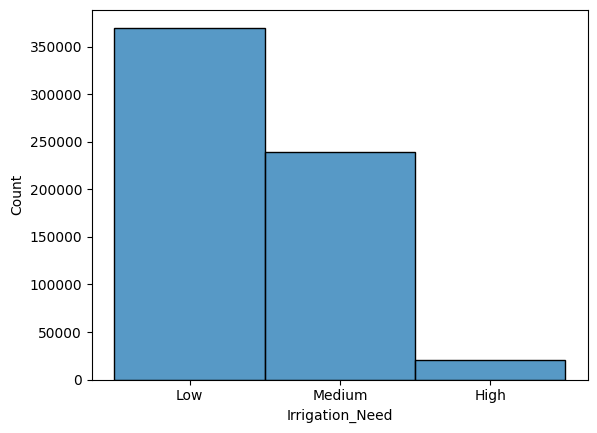

In [13]:
sns.histplot(x="Irrigation_Need",data=df)
plt.show()

In [14]:
mapp = {'Low': 0, 'Medium': 1, 'High': 2}
df['Irrigation_Need'] = df['Irrigation_Need'].map(mapp)

In [15]:
def feature(df):
    # Feature Engineering
    df['sun_temp'] = df['Temperature_C'] + df['Sunlight_Hours'] + df['Electrical_Conductivity']
    df['sun_temp_mois'] = df['Soil_Moisture'] / (df['sun_temp'] )  # +epsilon عشان منقسمش على صفر 
    df['Humidity_rain']  = df['Humidity'] / df['Rainfall_mm']        # water availability
    df['moisture_humidity'] =df['Soil_Moisture']  / df['Humidity']
    df['temp_soil'] = df['Temperature_C'] / df['Soil_Moisture']
    df['pre_irr / Rain'] = df['Previous_Irrigation_mm'] / df['Rainfall_mm']
    df['Temp_humid'] = df['Temperature_C'] / df['Humidity']
    # حذف Sunlight_Hours بعد استخدامه في الـ feature engineering
    df.drop(['Sunlight_Hours','Humidity','Previous_Irrigation_mm','Rainfall_mm'], axis=1, inplace=True)

    return df

In [16]:
# Feature Engineering
df = feature(df)
dftest = feature(dftest)

In [17]:
cat_cols = ['Soil_Type','Crop_Type','Irrigation_Type','Water_Source','Season','Region','Crop_Growth_Stage','Mulching_Used']
ord = OrdinalEncoder()
df[cat_cols] = ord.fit_transform(df[cat_cols])
dftest[cat_cols] = ord.transform(dftest[cat_cols])


<Axes: >

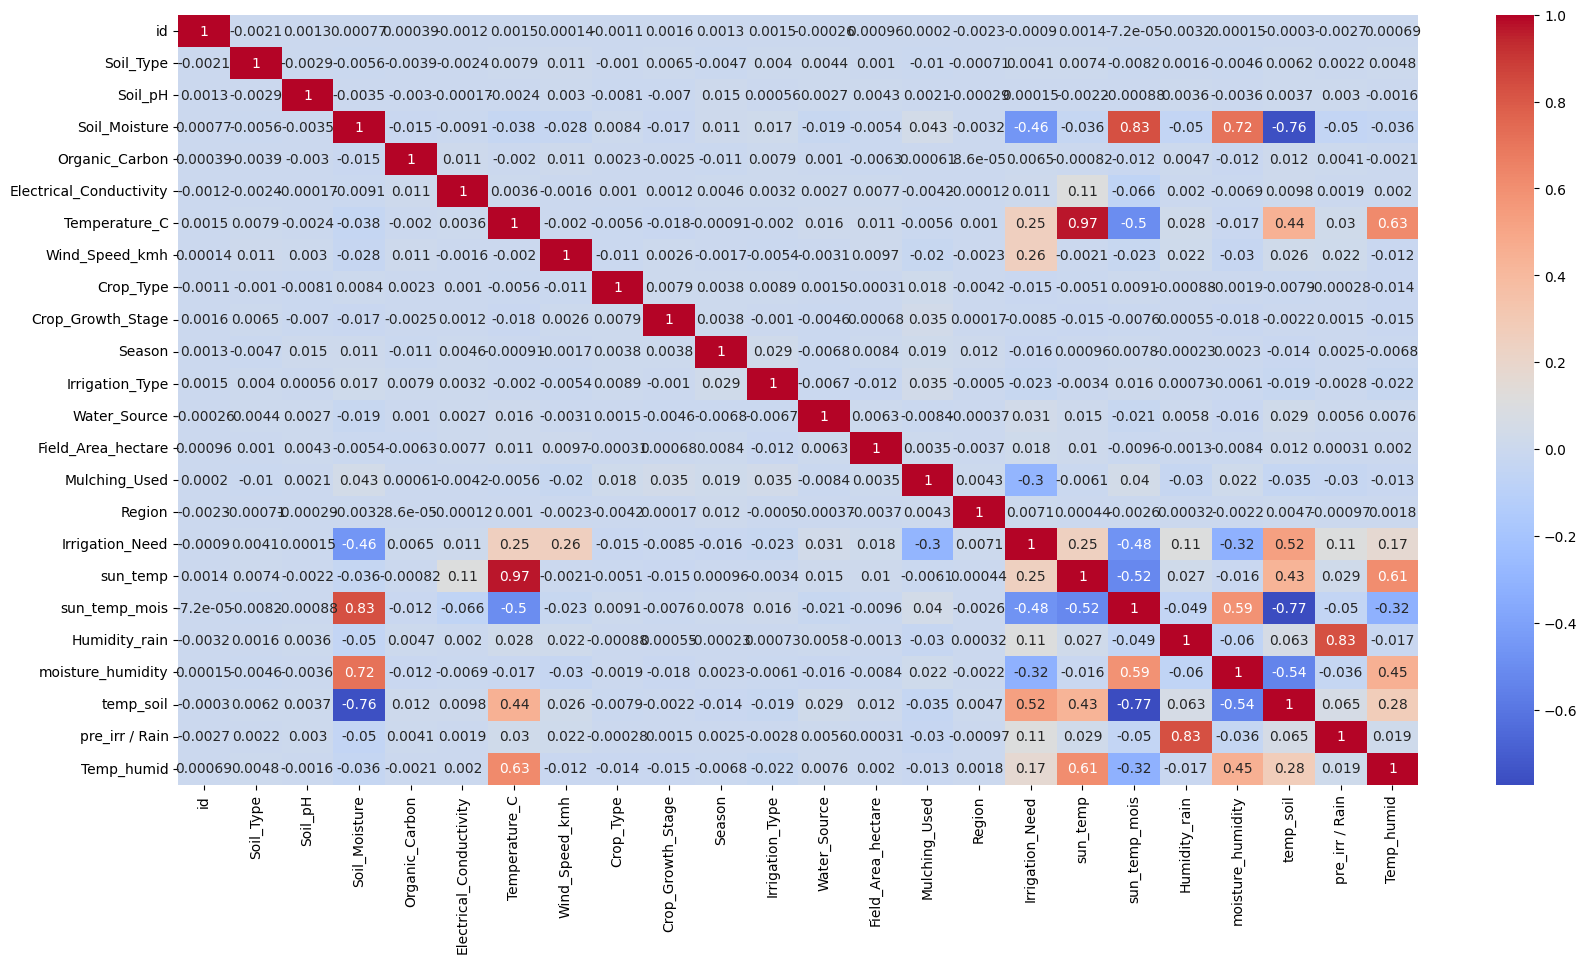

In [18]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(20,10))
sns.heatmap(corr,annot=True,cmap='coolwarm')

In [19]:
num_cols = [
    'Soil_pH','Soil_Moisture','Organic_Carbon','Electrical_Conductivity',
    'Temperature_C',
    'Wind_Speed_kmh','Field_Area_hectare',
]

scl = StandardScaler()
df[num_cols] = scl.fit_transform(df[num_cols])
dftest[num_cols] = scl.transform(dftest[num_cols])
df

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,...,Mulching_Used,Region,Irrigation_Need,sun_temp,sun_temp_mois,Humidity_rain,moisture_humidity,temp_soil,pre_irr / Rain,Temp_humid
0,0,1.0,-1.693757,-0.288482,0.238218,1.370753,-1.390156,1.127456,4.0,2.0,...,0.0,1.0,0,23.96,1.359766,0.069712,0.643746,0.460712,0.154492,0.296582
1,1,0.0,0.647697,1.178814,-1.319979,0.268182,-0.472907,-1.227779,5.0,3.0,...,1.0,3.0,0,31.90,1.774608,0.068847,0.834218,0.404875,0.047846,0.337754
2,2,0.0,-0.859072,-0.585849,-0.308518,1.139738,-0.003266,-1.146928,3.0,3.0,...,1.0,2.0,0,35.85,0.772943,0.041886,0.300477,0.973295,0.050134,0.292453
3,3,2.0,-0.902432,-1.464516,1.112995,-0.918393,-1.586129,-1.417604,5.0,0.0,...,1.0,3.0,1,23.31,0.571429,0.045361,0.216339,1.000000,0.039673,0.216339
4,4,0.0,1.601623,1.333298,-1.483999,-0.823887,-0.786001,0.626529,5.0,2.0,...,0.0,3.0,0,28.13,2.102382,0.059232,0.649105,0.341901,0.060584,0.221930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,0.0,0.062333,-1.456578,0.620933,0.121173,-0.040374,1.489529,3.0,2.0,...,0.0,3.0,1,39.13,0.343726,0.025794,0.500745,1.981413,0.113662,0.992182
629996,629996,0.0,0.593497,1.049365,0.101534,0.635706,1.158660,1.338372,4.0,3.0,...,1.0,0.0,1,49.27,1.105947,0.061991,0.619205,0.678840,0.028706,0.420341
629997,629997,0.0,0.040653,-1.546338,0.019524,-1.432926,1.254907,1.208307,2.0,3.0,...,1.0,3.0,2,46.39,0.258245,0.802487,0.168780,3.156928,0.029621,0.532826
629998,629998,0.0,-0.598911,0.339225,-1.620683,1.727775,0.926738,-0.944800,4.0,3.0,...,1.0,1.0,0,48.26,0.888106,0.038859,0.453161,0.816379,0.036977,0.369951


In [20]:
X = df.drop(["Irrigation_Need","id"],axis=1)
y = df['Irrigation_Need']
X_train , X_test , y_train , y_test = train_test_split(X ,y ,train_size=0.8 ,random_state=42)

In [21]:
smote = SMOTE(
    sampling_strategy='not majority',
    k_neighbors=3,
    random_state=42
)
X_train_smo, y_train_smo = smote.fit_resample(X_train, y_train)

print("SMOTE:", Counter(y_train_smo))

SMOTE: Counter({0: 296180, 2: 296180, 1: 296180})


In [ ]:
model = Sequential([
    Dense(256,activation='relu',input_shape=(X_train_smo.shape[1],)),
    Dense(128,activation='relu'),
    Dense(230,activation='relu',kernel_regularizer=L1(0.001)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(3, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 230)            │        29,670 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        29,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,473 (415.91 KB)

 Trainable params: 106,473 (415.91 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(optimizer=Adam(learning_rate=0.001, ema_momentum=0.99),
              #optimizer=SGD(momentum=0.9),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [24]:
early_Stopping = EarlyStopping(monitor='val_loss',patience=6)
model.fit(X_train_smo,y_train_smo,
          validation_split = 0.1,
          batch_size=230,
          epochs=30,
          callbacks=[early_Stopping])

Epoch 1/30
3477/3477 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8546 - loss: 0.3507 - val_accuracy: 0.9484 - val_loss: 0.1575
Epoch 2/30
3477/3477 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9350 - loss: 0.1778 - val_accuracy: 0.9365 - val_loss: 0.1832
Epoch 3/30
3477/3477 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9484 - loss: 0.1460 - val_accuracy: 0.9446 - val_loss: 0.1568
Epoch 4/30
3477/3477 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9557 - loss: 0.1278 - val_accuracy: 0.9418 - val_loss: 0.1606
Epoch 5/30
3477/3477 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9596 - loss: 0.1184 - val_accuracy: 0.9549 - val_loss: 0.1156
Epoch 6/30
3477/3477 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9623 - loss: 0.1116 - val_accuracy: 0.9571 - val_loss: 0.1041
Epoch 7/30
3477/3477 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9638 - loss: 0.1073 - val_accuracy: 0.9599 - val_loss: 0.0985
Epoch 8/30
3477/3477 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9652 - loss: 0.1040 -

In [25]:
model.evaluate(X_test,y_test)

3938/3938 ━━━━━━━━━━━━━━━━━━━━ 2s 631us/step - accuracy: 0.9771 - loss: 0.0813


[0.08134375512599945, 0.9771190285682678]

In [26]:
model.evaluate(X_train_smo,y_train_smo)

27767/27767 ━━━━━━━━━━━━━━━━━━━━ 17s 627us/step - accuracy: 0.9703 - loss: 0.0873


[0.08726123720407486, 0.9703344702720642]

In [27]:
from sklearn.metrics import balanced_accuracy_score
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

# Balanced Accuracy
bal_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy on Test Set: {bal_acc:.4f}")

3938/3938 ━━━━━━━━━━━━━━━━━━━━ 2s 457us/step
Balanced Accuracy on Test Set: 0.9565


In [28]:
model.save('best_model.h5')

[05-04-2026 12:41:18] [absl] [WARNING] You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 


In [29]:
from tensorflow.keras.models import load_model
load = load_model("best_model.h5")
load.evaluate(X_train, y_train)

[05-04-2026 12:41:18] [absl] [WARNING] Compiled the loaded model, but the compiled metrics have yet to be built. `model.compile_metrics` will be empty until you train or evaluate the model.


15750/15750 ━━━━━━━━━━━━━━━━━━━━ 10s 621us/step - accuracy: 0.9779 - loss: 0.0779


[0.07792628556489944, 0.9779106974601746]

In [30]:
sub = dftest[['id']]
dftest.drop('id', axis=1, inplace=True)
y_pred_sub = model.predict(dftest)
y_pred_sub = np.argmax(y_pred_sub, axis=1)
y_pred_sub

8438/8438 ━━━━━━━━━━━━━━━━━━━━ 4s 448us/step


array([0, 0, 0, ..., 1, 0, 1], shape=(270000,))

In [31]:
sub['Irrigation_Need'] = y_pred_sub

In [32]:
mappp = {0:'Low', 1:'Medium', 2:'High'}
sub['Irrigation_Need'] = sub['Irrigation_Need'].map(mappp)

In [33]:
sub.to_csv("sub1.csv", index=False)